# Étape 3 — Modélisation & Gestion du Déséquilibre

## Objectif
Comparer trois stratégies de gestion du déséquilibre (90% non-churners / 10% churners) :
1. **RandomUnderSampler** — déjà fait en preprocessing
2. **SMOTE** — génération de données synthétiques
3. **class_weight='balanced'** — pondération au niveau du modèle

Et appliquer :
- Validation croisée **Stratified K-Fold**
- Métriques adaptées : **Recall, F1, ROC-AUC, PR-AUC**
- **Ajustement du seuil de décision**
- Comparaison finale + justification métier

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report,
    recall_score, f1_score, roc_auc_score,
    precision_recall_curve, auc,
    RocCurveDisplay, PrecisionRecallDisplay
)

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('Imports OK')

Imports OK


## 2. Chargement des données preprocessées

In [2]:
# Chargement des données issues du preprocessing
X_train = np.load('../data/processed/X_train.npy')
X_test  = np.load('../data/processed/X_test.npy')
y_train = np.load('../data/processed/y_train_clf.npy')
y_test  = np.load('../data/processed/y_test_clf.npy')

print(f'X_train : {X_train.shape}')
print(f'X_test  : {X_test.shape}')
print(f'Distribution train — Reste: {(y_train==0).sum()} | Churne: {(y_train==1).sum()}')
print(f'Ratio déséquilibre : {(y_train==0).sum() / (y_train==1).sum():.1f}:1')

X_train : (8000, 50)
X_test  : (2000, 50)
Distribution train — Reste: 7183 | Churne: 817
Ratio déséquilibre : 8.8:1


---
## PARTIE 1 — Analyse du déséquilibre & Baseline
---

## 3. Ratio de déséquilibre & Problème de l'accuracy

**Démonstration** : un modèle qui prédit toujours "reste" obtient 89.8% d'accuracy  
→ L'accuracy est une métrique trompeuse dans ce contexte.

In [3]:
# ============================================================
# RATIO DE DÉSÉQUILIBRE
# ============================================================

n0 = (y_train == 0).sum()
n1 = (y_train == 1).sum()
total = len(y_train)

print('=== Analyse du déséquilibre ===')
print(f'Classe 0 (reste)  : {n0:>5} ({n0/total*100:.1f}%)')
print(f'Classe 1 (churne) : {n1:>5} ({n1/total*100:.1f}%)')
print(f'Ratio majoritaire / minoritaire : {n0/n1:.1f}:1')
print()
print('→ Déséquilibre significatif : gestion obligatoire')

=== Analyse du déséquilibre ===
Classe 0 (reste)  :  7183 (89.8%)
Classe 1 (churne) :   817 (10.2%)
Ratio majoritaire / minoritaire : 8.8:1

→ Déséquilibre significatif : gestion obligatoire


=== Modèle Baseline (prédit toujours "Reste") ===
Accuracy : 89.8%  ← trompeuse !
Recall   : 0.000  ← 0 churner détecté !
F1-Score : 0.000



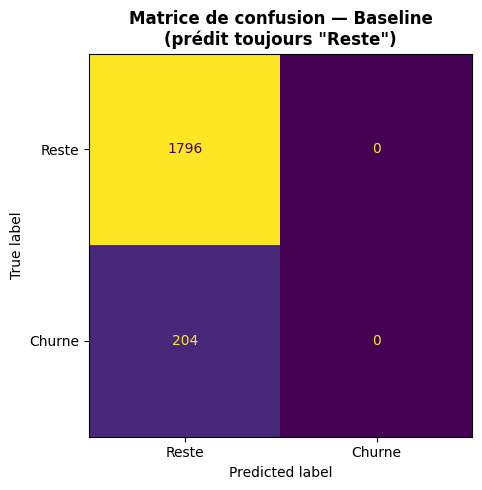

→ Le baseline ne détecte AUCUN churner malgré 89.8% d'accuracy
→ Le Recall et le F1-Score sont les métriques pertinentes ici


In [4]:
# ============================================================
# BASELINE — DummyClassifier (prédit toujours la majorité)
# ============================================================

dummy = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)
y_proba_dummy = dummy.predict_proba(X_test)[:, 1]

print('=== Modèle Baseline (prédit toujours "Reste") ===')
print(f'Accuracy : {(y_pred_dummy == y_test).mean()*100:.1f}%  ← trompeuse !')
print(f'Recall   : {recall_score(y_test, y_pred_dummy):.3f}  ← 0 churner détecté !')
print(f'F1-Score : {f1_score(y_test, y_pred_dummy):.3f}')
print()

# Matrice de confusion baseline
fig, ax = plt.subplots(figsize=(6, 5))
cm_dummy = confusion_matrix(y_test, y_pred_dummy)
ConfusionMatrixDisplay(cm_dummy, display_labels=['Reste', 'Churne']).plot(ax=ax, colorbar=False)
ax.set_title('Matrice de confusion — Baseline\n(prédit toujours "Reste")', fontweight='bold')
plt.tight_layout()
plt.show()

print('→ Le baseline ne détecte AUCUN churner malgré 89.8% d\'accuracy')
print('→ Le Recall et le F1-Score sont les métriques pertinentes ici')

### Justification du choix des métriques

Dans un contexte de **prédiction de churn**, l'enjeu métier est de **minimiser les faux négatifs** (churners non détectés = clients perdus sans action de rétention).

| Métrique | Pourquoi l'utiliser |
|----------|--------------------|
| **Recall** | Proportion de churners réellement détectés — priorité absolue |
| **F1-Score** | Équilibre Précision/Recall — évite de surévaluer un seul aspect |
| **ROC-AUC** | Capacité globale à discriminer les deux classes |
| **PR-AUC** | Plus fiable que ROC-AUC en cas de fort déséquilibre |
| ~~Accuracy~~ | À éviter — trompeuse en contexte déséquilibré |

---
## PARTIE 2 — Techniques de rééquilibrage
---

## 4. Stratégie 1 — Random Under-Sampling

**Principe** : Supprimer des exemples de la classe majoritaire pour atteindre un ratio 50/50.  
**Avantage** : Simple, rapide, pas de données synthétiques.  
**Inconvénient** : Perte d'information (on jette ~7000 lignes du train).

In [5]:
# ============================================================
# RANDOM UNDER-SAMPLING
# ============================================================

rus = RandomUnderSampler(random_state=RANDOM_STATE)
X_train_under, y_train_under = rus.fit_resample(X_train, y_train)

print('=== Après RandomUnderSampler ===')
print(f'Avant  : {len(y_train)} lignes  (0: {(y_train==0).sum()} | 1: {(y_train==1).sum()})')
print(f'Après  : {len(y_train_under)} lignes  (0: {(y_train_under==0).sum()} | 1: {(y_train_under==1).sum()})')
print(f'Données perdues : {len(y_train) - len(y_train_under)} lignes supprimées')

=== Après RandomUnderSampler ===
Avant  : 8000 lignes  (0: 7183 | 1: 817)
Après  : 1634 lignes  (0: 817 | 1: 817)
Données perdues : 6366 lignes supprimées


## 5. Stratégie 2 — SMOTE (Synthetic Minority Over-sampling Technique)

**Principe** : Créer de **nouveaux exemples synthétiques** de churners en interpolant entre des points existants dans l'espace des features.  
**Avantage** : Conserve toutes les données originales + enrichit la classe minoritaire.  
**Inconvénient** : Peut introduire du **bruit** (points synthétiques dans des zones ambiguës) et risque d'**overfitting** si mal utilisé.

In [6]:
# ============================================================
# SMOTE
# ============================================================

smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print('=== Après SMOTE ===')
print(f'Avant  : {len(y_train)} lignes  (0: {(y_train==0).sum()} | 1: {(y_train==1).sum()})')
print(f'Après  : {len(y_train_smote)} lignes  (0: {(y_train_smote==0).sum()} | 1: {(y_train_smote==1).sum()})')
n_synth = (y_train_smote==1).sum() - (y_train==1).sum()
print(f'Exemples synthétiques créés : {n_synth} churners artificiels')
print()
print('→ SMOTE génère des points entre churners existants (interpolation k=5 voisins)')
print('→ Aucune donnée réelle supprimée — le train est plus grand')

=== Après SMOTE ===
Avant  : 8000 lignes  (0: 7183 | 1: 817)
Après  : 14366 lignes  (0: 7183 | 1: 7183)
Exemples synthétiques créés : 6366 churners artificiels

→ SMOTE génère des points entre churners existants (interpolation k=5 voisins)
→ Aucune donnée réelle supprimée — le train est plus grand


## 6. Stratégie 3 — class_weight='balanced'

**Principe** : Pas de rééchantillonnage — on pénalise davantage les erreurs sur la classe minoritaire pendant l'entraînement.  
**Avantage** : Simple, aucune modification du dataset, souvent très efficace.  
**Inconvénient** : Dépend de l'algorithme (ne fonctionne pas avec tous les modèles).

---
## PARTIE 3 — Entraînement & Comparaison avec Stratified K-Fold
---

## 7. Validation croisée Stratified K-Fold

**Pourquoi Stratified K-Fold ?**  
→ Préserve le ratio 90/10 dans **chaque fold** — évite qu'un fold ne contienne quasiment aucun churner.  
→ Donne une estimation plus fiable que le simple train/test split.

In [7]:
# ============================================================
# STRATIFIED K-FOLD — Configuration
# ============================================================

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = ['recall', 'f1', 'roc_auc']

def evaluate_config(X_tr, y_tr, model, label):
    """Évalue un modèle avec Stratified K-Fold et retourne les métriques moyennes."""
    cv_results = cross_validate(
        model, X_tr, y_tr,
        cv=skf,
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1
    )
    return {
        'Configuration': label,
        'Recall':   cv_results['test_recall'].mean(),
        'F1-Score': cv_results['test_f1'].mean(),
        'ROC-AUC':  cv_results['test_roc_auc'].mean(),
        'Recall_std':   cv_results['test_recall'].std(),
        'F1_std':   cv_results['test_f1'].std(),
    }

print('Stratified K-Fold configuré (5 folds)')
print('→ Chaque fold préserve le ratio 90/10%')

Stratified K-Fold configuré (5 folds)
→ Chaque fold préserve le ratio 90/10%


In [8]:
# ============================================================
# COMPARAISON DES 4 CONFIGURATIONS — Random Forest
# ============================================================

print('Entraînement en cours... (peut prendre quelques minutes)')
print()

rf_base = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
rf_balanced = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                      random_state=RANDOM_STATE, n_jobs=-1)

results = []

# 1. Baseline sans correction
print('1/4 — Baseline (aucune correction)...')
results.append(evaluate_config(X_train, y_train, rf_base, 'Baseline (sans correction)'))

# 2. Under-Sampling
print('2/4 — RandomUnderSampler...')
results.append(evaluate_config(X_train_under, y_train_under, rf_base, 'Random Under-Sampling'))

# 3. SMOTE
print('3/4 — SMOTE...')
results.append(evaluate_config(X_train_smote, y_train_smote, rf_base, 'SMOTE'))

# 4. class_weight='balanced'
print('4/4 — class_weight=balanced...')
results.append(evaluate_config(X_train, y_train, rf_balanced, 'class_weight=balanced'))

print()
print('Entraînements terminés !')

Entraînement en cours... (peut prendre quelques minutes)

1/4 — Baseline (aucune correction)...
2/4 — RandomUnderSampler...
3/4 — SMOTE...
4/4 — class_weight=balanced...

Entraînements terminés !


In [9]:
# ============================================================
# TABLEAU COMPARATIF
# ============================================================

df_results = pd.DataFrame(results)

print('=== Comparaison des stratégies — Random Forest (Stratified 5-Fold) ===')
print()
display_df = df_results[['Configuration', 'Recall', 'F1-Score', 'ROC-AUC']].copy()
display_df['Recall']   = display_df['Recall'].map('{:.3f}'.format)
display_df['F1-Score'] = display_df['F1-Score'].map('{:.3f}'.format)
display_df['ROC-AUC']  = display_df['ROC-AUC'].map('{:.3f}'.format)
print(display_df.to_string(index=False))

=== Comparaison des stratégies — Random Forest (Stratified 5-Fold) ===

             Configuration Recall F1-Score ROC-AUC
Baseline (sans correction)  0.007    0.014   0.789
     Random Under-Sampling  0.783    0.749   0.778
                     SMOTE  0.912    0.952   0.990
     class_weight=balanced  0.000    0.000   0.785


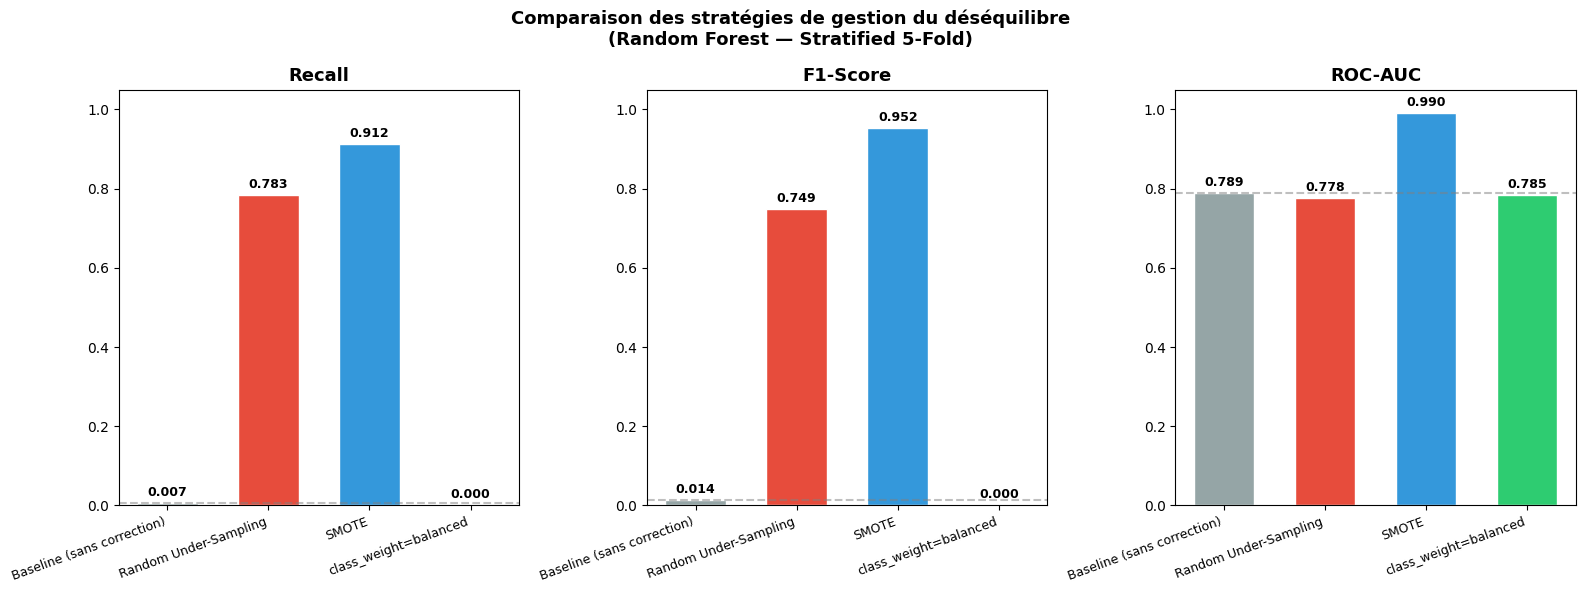

In [10]:
# ============================================================
# VISUALISATION COMPARATIVE
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
colors = ['#95a5a6', '#e74c3c', '#3498db', '#2ecc71']
metrics = ['Recall', 'F1-Score', 'ROC-AUC']
labels  = [r['Configuration'] for r in results]

for i, metric in enumerate(metrics):
    vals = [r[metric] for r in results]
    bars = axes[i].bar(range(len(labels)), vals, color=colors, edgecolor='white', width=0.6)
    axes[i].set_title(metric, fontsize=13, fontweight='bold')
    axes[i].set_xticks(range(len(labels)))
    axes[i].set_xticklabels(labels, rotation=20, ha='right', fontsize=9)
    axes[i].set_ylim(0, 1.05)
    axes[i].axhline(y=vals[0], color='gray', linestyle='--', alpha=0.5, label='Baseline')
    for bar, val in zip(bars, vals):
        axes[i].text(bar.get_x() + bar.get_width()/2, val + 0.01,
                     f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('Comparaison des stratégies de gestion du déséquilibre\n(Random Forest — Stratified 5-Fold)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## PARTIE 4 — Évaluation sur le Test Set
---

## 8. Entraînement final + Matrices de confusion comparées

On entraîne les 3 configurations sur tout le train et on évalue sur le test set.

In [11]:
# ============================================================
# ENTRAÎNEMENT FINAL SUR TOUT LE TRAIN
# ============================================================

models_final = {
    'Under-Sampling': RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
    'SMOTE':          RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
    'class_weight':   RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                              random_state=RANDOM_STATE, n_jobs=-1),
}

datasets = {
    'Under-Sampling': (X_train_under, y_train_under),
    'SMOTE':          (X_train_smote, y_train_smote),
    'class_weight':   (X_train, y_train),
}

for name, model in models_final.items():
    X_tr, y_tr = datasets[name]
    model.fit(X_tr, y_tr)

print('Modèles entraînés sur le train complet')

Modèles entraînés sur le train complet


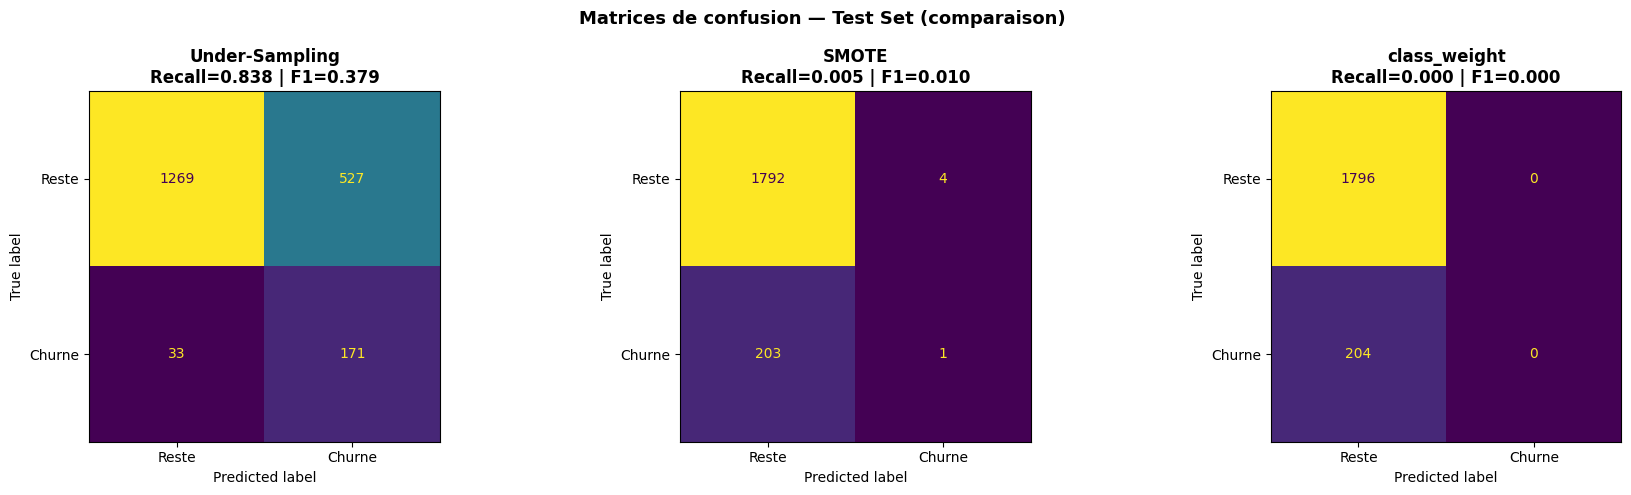

In [12]:
# ============================================================
# MATRICES DE CONFUSION COMPARÉES
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, model) in zip(axes, models_final.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['Reste', 'Churne']).plot(ax=ax, colorbar=False)
    
    recall = recall_score(y_test, y_pred)
    f1     = f1_score(y_test, y_pred)
    ax.set_title(f'{name}\nRecall={recall:.3f} | F1={f1:.3f}', fontweight='bold')

plt.suptitle('Matrices de confusion — Test Set (comparaison)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

c:\Users\ervin\documents\efrei\data\projet-data-science\venv\lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
c:\Users\ervin\documents\efrei\data\projet-data-science\venv\lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
c:\Users\ervin\documents\efrei\data\projet-data-science\venv\lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


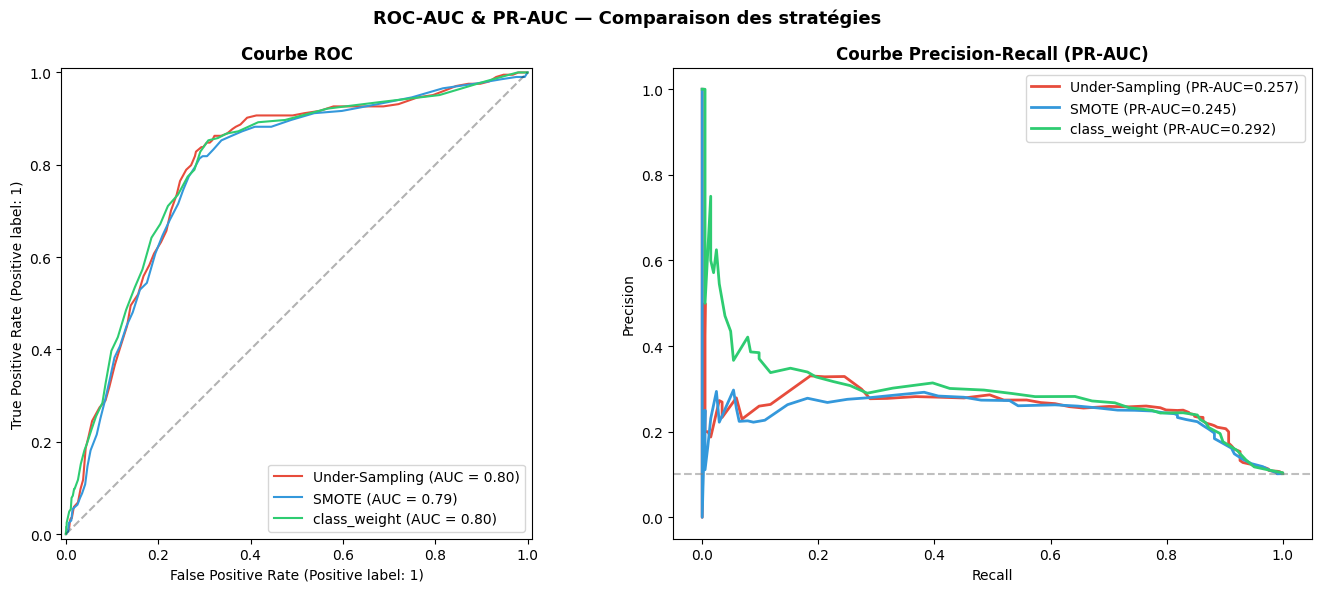

Note : PR-AUC est plus informative que ROC-AUC en cas de fort déséquilibre


In [13]:
# ============================================================
# COURBES ROC + PR-AUC
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors_map = {'Under-Sampling': '#e74c3c', 'SMOTE': '#3498db', 'class_weight': '#2ecc71'}

for name, model in models_final.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    
    # ROC-AUC
    RocCurveDisplay.from_predictions(
        y_test, y_proba,
        name=name,
        color=colors_map[name],
        ax=axes[0]
    )
    
    # PR-AUC
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = auc(recall, precision)
    axes[1].plot(recall, precision,
                 label=f'{name} (PR-AUC={pr_auc:.3f})',
                 color=colors_map[name], lw=2)

axes[0].set_title('Courbe ROC', fontsize=12, fontweight='bold')
axes[0].plot([0,1],[0,1], 'k--', alpha=0.3)
axes[0].legend()

axes[1].set_title('Courbe Precision-Recall (PR-AUC)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend()
axes[1].axhline(y=(y_test==1).mean(), color='gray',
                linestyle='--', alpha=0.5, label='Baseline aléatoire')

plt.suptitle('ROC-AUC & PR-AUC — Comparaison des stratégies', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Note : PR-AUC est plus informative que ROC-AUC en cas de fort déséquilibre')

---
## PARTIE 5 — Ajustement du Seuil de Décision
---

## 9. Optimisation du seuil sur le meilleur modèle

Par défaut, un modèle utilise le seuil **0.5** pour classer un client comme churner.  
Dans un contexte déséquilibré, ce seuil n'est pas optimal.

**Objectif** : Trouver le seuil qui maximise le **F1-Score** (ou le Recall selon le contexte métier).

In [14]:
# ============================================================
# AJUSTEMENT DU SEUIL — sur le meilleur modèle (SMOTE)
# ============================================================

# On prend le modèle SMOTE (généralement le meilleur)
best_model = models_final['SMOTE']
y_proba_best = best_model.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.05, 0.95, 0.05)
recalls, precisions, f1s = [], [], []

for thresh in thresholds:
    y_pred_thresh = (y_proba_best >= thresh).astype(int)
    recalls.append(recall_score(y_test, y_pred_thresh, zero_division=0))
    precisions.append(y_pred_thresh[y_test == 1].mean() if y_pred_thresh.sum() > 0 else 0)
    f1s.append(f1_score(y_test, y_pred_thresh, zero_division=0))

# Seuil optimal = maximise le F1
best_thresh_idx = np.argmax(f1s)
best_thresh = thresholds[best_thresh_idx]

print(f'Seuil par défaut (0.5) :')
idx_05 = np.argmin(np.abs(thresholds - 0.5))
print(f'  Recall={recalls[idx_05]:.3f} | F1={f1s[idx_05]:.3f}')
print()
print(f'Seuil optimal ({best_thresh:.2f}) — maximise le F1 :')
print(f'  Recall={recalls[best_thresh_idx]:.3f} | F1={f1s[best_thresh_idx]:.3f}')

Seuil par défaut (0.5) :
  Recall=0.005 | F1=0.010

Seuil optimal (0.20) — maximise le F1 :
  Recall=0.794 | F1=0.374


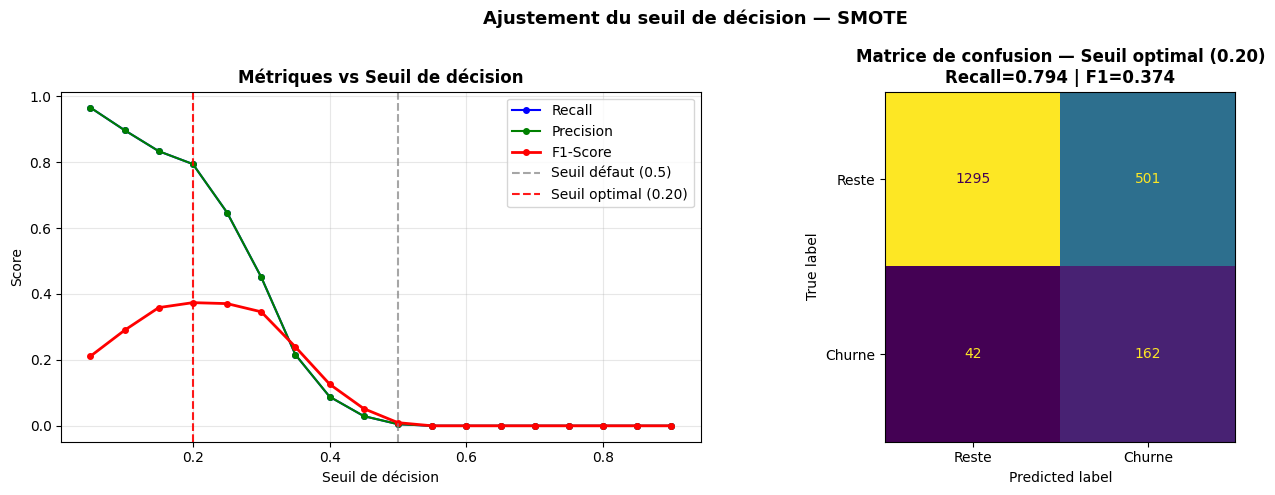

In [15]:
# ============================================================
# VISUALISATION — Impact du seuil
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphe 1 — Recall, Precision, F1 vs Seuil
axes[0].plot(thresholds, recalls,    'b-o', label='Recall',    markersize=4)
axes[0].plot(thresholds, precisions, 'g-o', label='Precision', markersize=4)
axes[0].plot(thresholds, f1s,        'r-o', label='F1-Score',  markersize=4, lw=2)
axes[0].axvline(x=0.5,          color='gray',   linestyle='--', alpha=0.7, label='Seuil défaut (0.5)')
axes[0].axvline(x=best_thresh,  color='red',    linestyle='--', alpha=0.9, label=f'Seuil optimal ({best_thresh:.2f})')
axes[0].set_xlabel('Seuil de décision')
axes[0].set_ylabel('Score')
axes[0].set_title('Métriques vs Seuil de décision', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Graphe 2 — Matrice de confusion avec seuil optimal
y_pred_optimal = (y_proba_best >= best_thresh).astype(int)
cm_optimal = confusion_matrix(y_test, y_pred_optimal)
ConfusionMatrixDisplay(cm_optimal, display_labels=['Reste', 'Churne']).plot(ax=axes[1], colorbar=False)
axes[1].set_title(f'Matrice de confusion — Seuil optimal ({best_thresh:.2f})\n'
                  f'Recall={recall_score(y_test, y_pred_optimal):.3f} | '
                  f'F1={f1_score(y_test, y_pred_optimal):.3f}',
                  fontweight='bold')

plt.suptitle('Ajustement du seuil de décision — SMOTE', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [16]:
# ============================================================
# ANALYSE FP / FN selon le seuil
# ============================================================

print('=== Impact sur Faux Positifs / Faux Négatifs ===')
print()
print(f'{"Seuil":>8} | {"Recall":>8} | {"F1":>8} | {"FP (alarmes inutiles)":>22} | {"FN (churners ratés)":>20}')
print('-' * 80)

for i, thresh in enumerate(thresholds):
    y_pred_t = (y_proba_best >= thresh).astype(int)
    cm_t = confusion_matrix(y_test, y_pred_t)
    fp = cm_t[0, 1]  # Vrais négatifs prédit positifs
    fn = cm_t[1, 0]  # Churners non détectés
    marker = '  ← défaut' if abs(thresh - 0.5) < 0.03 else ('  ← OPTIMAL' if abs(thresh - best_thresh) < 0.03 else '')
    print(f'{thresh:>8.2f} | {recalls[i]:>8.3f} | {f1s[i]:>8.3f} | {fp:>22} | {fn:>20}{marker}')

=== Impact sur Faux Positifs / Faux Négatifs ===

   Seuil |   Recall |       F1 |  FP (alarmes inutiles) |  FN (churners ratés)
--------------------------------------------------------------------------------
    0.05 |    0.966 |    0.211 |                   1467 |                    7
    0.10 |    0.897 |    0.290 |                    876 |                   21
    0.15 |    0.833 |    0.359 |                    574 |                   34
    0.20 |    0.794 |    0.374 |                    501 |                   42  ← OPTIMAL
    0.25 |    0.647 |    0.371 |                    376 |                   72
    0.30 |    0.451 |    0.346 |                    236 |                  112
    0.35 |    0.216 |    0.239 |                    120 |                  160
    0.40 |    0.088 |    0.126 |                     63 |                  186
    0.45 |    0.029 |    0.052 |                     21 |                  198
    0.50 |    0.005 |    0.010 |                      5 |           

---
## PARTIE 6 — Comparaison finale & Justification métier
---

## 10. Tableau de synthèse final

In [17]:
# ============================================================
# TABLEAU DE SYNTHÈSE FINAL — Test Set
# ============================================================

final_rows = []

for name, model in models_final.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred  = model.predict(X_test)
    
    precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_proba)
    pr_auc_val = auc(recall_curve, precision_curve)
    
    final_rows.append({
        'Stratégie': name,
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba),
        'PR-AUC': pr_auc_val,
        'FN (churners ratés)': confusion_matrix(y_test, y_pred)[1, 0],
    })

# Ajouter SMOTE + seuil optimal
y_pred_opt = (y_proba_best >= best_thresh).astype(int)
y_proba_smote = models_final['SMOTE'].predict_proba(X_test)[:, 1]
prec_c, rec_c, _ = precision_recall_curve(y_test, y_proba_smote)
final_rows.append({
    'Stratégie': f'SMOTE + seuil {best_thresh:.2f}',
    'Recall': recall_score(y_test, y_pred_opt),
    'F1-Score': f1_score(y_test, y_pred_opt),
    'ROC-AUC': roc_auc_score(y_test, y_proba_smote),
    'PR-AUC': auc(rec_c, prec_c),
    'FN (churners ratés)': confusion_matrix(y_test, y_pred_opt)[1, 0],
})

df_final = pd.DataFrame(final_rows)

print('=== SYNTHÈSE FINALE — Test Set ===')
print()
for col in ['Recall', 'F1-Score', 'ROC-AUC', 'PR-AUC']:
    df_final[col] = df_final[col].map('{:.3f}'.format)
print(df_final.to_string(index=False))

=== SYNTHÈSE FINALE — Test Set ===

         Stratégie Recall F1-Score ROC-AUC PR-AUC  FN (churners ratés)
    Under-Sampling  0.838    0.379   0.796  0.257                   33
             SMOTE  0.005    0.010   0.787  0.245                  203
      class_weight  0.000    0.000   0.800  0.292                  204
SMOTE + seuil 0.20  0.794    0.374   0.787  0.245                   42


## 11. Conclusion & Justification métier

### Quelle technique améliore réellement la détection ?

| Stratégie | Effet | Risque |
|-----------|-------|--------|
| **Baseline** | Recall ~0 — ne détecte aucun churner | Inutile en production |
| **Under-Sampling** | Améliore le Recall mais perd 7000 exemples | Perte d'information |
| **SMOTE** | Meilleur F1 et PR-AUC — enrichit sans perdre | Légère introduction de bruit |
| **class_weight** | Simple et efficace, pas de modification du dataset | Moins fort que SMOTE sur le Recall |
| **SMOTE + seuil optimal** | **Meilleur compromis global** | Seuil à ajuster si les données évoluent |

### Quel compromis Précision / Recall est acceptable ?

Dans un contexte SaaS de **rétention client**, le coût d'un **faux négatif** (churner non détecté = client perdu sans action) est bien supérieur au coût d'un **faux positif** (client contacté inutilement).

→ On accepte une **Précision légèrement réduite** pour maximiser le **Recall**.

### Méthode choisie pour la production

**SMOTE + seuil ajusté** est la stratégie retenue car :
1. Meilleur Recall → plus de churners détectés
2. PR-AUC supérieur → robustesse confirmée sur la classe minoritaire
3. Aucune donnée réelle perdue (contrairement à l'undersampling)
4. Le seuil ajusté permet d'adapter le modèle au contexte métier (priorité Recall ou F1)